# Task 1 — Direct Clarity Classification

Fine‑tuning di **Llama 3.1 8B‑Instruct** (4‑bit QLoRA + DoRA) per classificare direttamente la chiarezza di una risposta politica nelle 3 macro‑categorie: **Ambivalent**, **Clear Reply**, **Clear Non‑Reply**.

In [1]:
# ============================================================
# CELLA 1 — Setup Ambiente
# ============================================================

import os, sys, json, gc
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from huggingface_hub import login
from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    BitsAndBytesConfig, TrainingArguments,
)
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer
from datasets import load_from_disk
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix

try:
    import yaml
except ImportError as exc:
    raise ImportError("Missing dependency: PyYAML. Install with `pip install pyyaml`.") from exc

# Configurazione dei percorsi e rilevamento ambiente (Colab / Locale)
try:
    import google.colab
    from google.colab import drive, userdata
    drive.mount('/content/drive', force_remount=True)

    # Percorsi base su Google Drive
    BASE_DIR = "/content/drive/MyDrive/progettoLLM"
    REPO_DIR = os.path.join(BASE_DIR, "CLARITY")
    hf_cache_dir = os.path.join(BASE_DIR, "hf_cache")
    
    os.makedirs(hf_cache_dir, exist_ok=True)
    os.environ["HF_HOME"] = hf_cache_dir
    
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)

    # Login HF tramite Colab Secrets
    hf_token = userdata.get('HF_TOKEN')
    os.environ['HF_TOKEN'] = hf_token
    login(token=hf_token)
    print(f"Ambiente Google Colab configurato. Cache: {hf_cache_dir}")

except ImportError:
    # Percorsi base in locale
    BASE_DIR = ".."
    REPO_DIR = BASE_DIR
    
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)

    # Lettura del token da file .env locale (cerca prima in CLARITY, poi nella root)
    env_path = os.path.join(REPO_DIR, ".env")
    if not os.path.exists(env_path):
        env_path = ".env"
        
    if os.path.exists(env_path):
        with open(env_path) as f:
            for line in f:
                if line.startswith("HF_TOKEN="):
                    hf_token = line.split("=", 1)[1].strip().strip("'\"")
                    os.environ['HF_TOKEN'] = hf_token
                    login(token=hf_token)
                    break
    print("Ambiente locale rilevato.")

print(f"Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Ambiente locale rilevato.
Device: NVIDIA GeForce RTX 2080 Ti


In [2]:
# ============================================================
# CELLA 2 — Variabili e Prompt
# ============================================================

# Config da file
CONFIG_PATH = os.path.join(REPO_DIR, "config", "config.yml")
with open(CONFIG_PATH, "r") as f:
    config = yaml.safe_load(f) or {}

# Flag di controllo
ESEGUI_TRAINING = bool(config.get("training", {}).get("enabled", True))

# Modello e percorsi
MODEL_ID = config.get("model", {}).get("id", "meta-llama/Llama-3.2-3B-Instruct")

# 1. Cartella Base Sicura (Fuori dalla repo CLARITY)
RES_DIR = os.path.join(REPO_DIR, config.get("paths", {}).get("results_dir", "results"))

TASK1_DIR = os.path.join(REPO_DIR, config.get("paths", {}).get("task1_dir", "results/task1"))

# 2. Percorsi specifici costruiti dinamicamente
OUTPUT_DIR = os.path.join(TASK1_DIR, "checkpoints")
PATH_MODELLO_SALVATO = os.path.join(TASK1_DIR, "modello_finale")

# Training params (Task 1)
TRAINING_CONFIG = config.get("training", {}).get("task1", {})
SEED = config.get("training", {}).get("seed", 42)
PER_DEVICE_TRAIN_BATCH_SIZE = TRAINING_CONFIG.get("batch_size", 2)
GRADIENT_ACCUMULATION_STEPS = TRAINING_CONFIG.get("gradient_accumulation_steps", 4)
NUM_TRAIN_EPOCHS = TRAINING_CONFIG.get("num_train_epochs", 1)

# Dataset/augmentation config
DATASET_CONFIG = config.get("dataset", {})
DATASET_USE_AUGMENTED = bool(DATASET_CONFIG.get("use_augmented", False))
AUGMENTATION_NAME = DATASET_CONFIG.get("augmentation", {}).get("name", "none")
AUGMENTATION_PARAMS = DATASET_CONFIG.get("augmentation", {}).get("params", {})

# Precisione: bfloat16 se supportato (L4/A100), altrimenti float16 (T4)
COMPUTE_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print(f"Compute dtype: {COMPUTE_DTYPE}")

# System prompt per la classificazione diretta a 3 classi
SYSTEM_PROMPT_TASK1 = """Sei un esperto analista di discorsi politici. Il tuo compito è classificare la risposta di un politico a una domanda diretta in una delle seguenti 3 categorie:

1. 'Clear Reply': La risposta ammette una sola interpretazione chiara.
2. 'Ambivalent': Viene fornita una risposta, ma è strutturata in modo da prestarsi a molteplici interpretazioni o essere vaga.
3. 'Clear Non-Reply': Il rispondente rifiuta apertamente o dichiara di non poter fornire le informazioni richieste.

Rispondi SOLO con il nome esatto della categoria (Clear Reply, Ambivalent o Clear Non-Reply), senza aggiungere altro testo."""

# Etichette nell'ordine usato per i report
LABELS = ["Ambivalent", "Clear Reply", "Clear Non-Reply"]

print("Configurazione caricata.")

Compute dtype: torch.bfloat16
Configurazione caricata.


In [3]:
# ============================================================
# CELLA 3 — Dataset Management
# ============================================================

from datasets import DatasetDict
from src.data.augmentation import get_augmentation_fn
from src.data.label_utils import build_label_maps

# Caricamento tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Caricamento split train e test utilizzando REPO_DIR
TRAIN_DATA_PATH = os.path.join(REPO_DIR, DATASET_CONFIG.get("train_path", "dataset/QEvasion/train"))
TEST_DATA_PATH = os.path.join(REPO_DIR, DATASET_CONFIG.get("test_path", "dataset/QEvasion/test"))

train_dataset = load_from_disk(TRAIN_DATA_PATH)
test_dataset  = load_from_disk(TEST_DATA_PATH)
print(f"Train: {len(train_dataset)} esempi | Test: {len(test_dataset)} esempi")

if DATASET_USE_AUGMENTED:
    if "evasion_label" not in train_dataset.column_names:
        print("Augmentation skipped: 'evasion_label' not found in train split.")
    else:
        ds = DatasetDict({"train": train_dataset, "validation": test_dataset, "test": test_dataset})
        label2id, _ = build_label_maps(ds)
        augment_fn = get_augmentation_fn(AUGMENTATION_NAME)
        ds = augment_fn(ds, label2id, **AUGMENTATION_PARAMS)
        train_dataset = ds["train"]
        print(f"Augmentation applied: {AUGMENTATION_NAME}")

def format_prompt_task1(example):
    """Formatta un esempio nel template chat di Llama 3.1 per il Task 1."""
    domanda  = example.get('interview_question', '')
    risposta = example.get('interview_answer', '')
    label    = example.get('clarity_label', '')

    messages = [
        {"role": "system",    "content": SYSTEM_PROMPT_TASK1},
        {"role": "user",      "content": f"Domanda: {domanda}\nRisposta del politico: {risposta}"},
        {"role": "assistant", "content": str(label)},
    ]
    return {"text": tokenizer.apply_chat_template(messages, tokenize=False)}

# Formattazione del training set
formatted_train = train_dataset.map(format_prompt_task1, remove_columns=train_dataset.column_names)

print("\n--- Esempio di prompt formattato ---")
print(formatted_train[0]["text"][:500] + "\n...")

Train: 3448 esempi | Test: 308 esempi

--- Esempio di prompt formattato ---
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 09 May 2026

Sei un esperto analista di discorsi politici. Il tuo compito è classificare la risposta di un politico a una domanda diretta in una delle seguenti 3 categorie:

1. 'Clear Reply': La risposta ammette una sola interpretazione chiara.
2. 'Ambivalent': Viene fornita una risposta, ma è strutturata in modo da prestarsi a molteplici interpretazioni o essere vaga.
3. 'Clear Non-Rep
...


In [ ]:
# ============================================================
# CELLA 4 — Core Logico (Training o Loading)
# ============================================================

# Pulizia preventiva VRAM per evitare OOM
torch.cuda.empty_cache()
gc.collect()

# Configurazione quantizzazione 4-bit comune
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=COMPUTE_DTYPE,
)

if ESEGUI_TRAINING:
    # ── TRAINING ──────────────────────────────────────────────
    print("Modalità TRAINING attiva.")

    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, device_map="auto",
        quantization_config=bnb_config, torch_dtype=COMPUTE_DTYPE,
    )
    model = prepare_model_for_kbit_training(model)

    # Configurazione DoRA sui layer di attenzione di Llama
    peft_config = LoraConfig(
        r=16, lora_alpha=32,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
        lora_dropout=0.05, bias="none",
        task_type="CAUSAL_LM", use_dora=False,
    )
    model = get_peft_model(model, peft_config)
    model.print_trainable_parameters()

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    training_args = TrainingArguments(
        output_dir=OUTPUT_DIR,
        per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        optim="paged_adamw_8bit",
        save_strategy="epoch",
        logging_steps=10,
        learning_rate=2e-4,
        weight_decay=0.001,
        fp16=(COMPUTE_DTYPE == torch.float16),
        bf16=(COMPUTE_DTYPE == torch.bfloat16),
        max_grad_norm=0.3,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        warmup_steps=100,
        group_by_length=True,
        lr_scheduler_type="cosine",
        report_to="none",
        seed=SEED,
    )

    trainer = SFTTrainer(
        model=model,
        train_dataset=formatted_train,
        args=training_args,
        peft_config=None,          # modello già wrappato con PEFT
        processing_class=tokenizer,
    )

    print("Inizio addestramento...")
    trainer.train()

    # Salvataggio adattatori + tokenizer su Drive
    trainer.model.save_pretrained(PATH_MODELLO_SALVATO)
    tokenizer.save_pretrained(PATH_MODELLO_SALVATO)
    print(f"Modello salvato in: {PATH_MODELLO_SALVATO}")

else:
    # ── CARICAMENTO DA CHECKPOINT ─────────────────────────────
    print(f"Caricamento modello base ({MODEL_ID}) in 4-bit...")

    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, device_map="auto",
        quantization_config=bnb_config, torch_dtype=COMPUTE_DTYPE,
    )

    print(f"Applicazione adattatori LoRA da: {PATH_MODELLO_SALVATO}")
    model = PeftModel.from_pretrained(
        base_model, PATH_MODELLO_SALVATO,
        low_cpu_mem_usage=True, device_map="auto",
    )

    # Sovrascriviamo il tokenizer con quello salvato col checkpoint
    tokenizer = AutoTokenizer.from_pretrained(PATH_MODELLO_SALVATO)
    print("Modello e adattatori caricati.")

model.eval()
print(f"Modello in eval mode. Device: {model.device}")

Modalità TRAINING attiva.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

trainable params: 9,175,040 || all params: 3,221,924,864 || trainable%: 0.2848


No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


🚀 Inizio addestramento...


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.
/mnt/Shared-Data/Code/github/itsPinguiz/LLMproject/CLARITY/.venv/lib/python3.12/site-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
10,2.841700
20,2.704200
30,2.458900
40,1.827800
50,0.739400
60,2.119000
70,1.904100
80,1.652700
90,1.099200
100,0.544000


Modello salvato in: ../results/task1/modello_finale
Modello in eval mode. Device: cuda:0


In [5]:
# ============================================================
# CELLA 5 — Funzione di Inferenza
# ============================================================

def predici_clarity(domanda: str, risposta: str) -> str:
    """
    Predice la macro-categoria di chiarezza per una coppia domanda/risposta.
    Restituisce una stringa tra: 'Clear Reply', 'Ambivalent', 'Clear Non-Reply'.
    """
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT_TASK1},
        {"role": "user",   "content": f"Domanda: {domanda}\nRisposta del politico: {risposta}"},
    ]
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=10,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated_ids = outputs[0][inputs['input_ids'].shape[-1]:]
    return tokenizer.decode(generated_ids, skip_special_tokens=True).strip()


# Sanity check rapido
print("--- Sanity check (3 esempi) ---")
for i in range(min(3, len(test_dataset))):
    es = test_dataset[i]
    pred = predici_clarity(es['interview_question'], es['interview_answer'])
    vero = str(es.get('clarity_label', '')).strip()
    ok = '✅' if pred == vero else '❌'
    print(f"  [{i+1}] Pred: {pred:20s} | Vera: {vero:20s} {ok}")

--- Sanity check (3 esempi) ---


/mnt/Shared-Data/Code/github/itsPinguiz/LLMproject/CLARITY/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.6` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/mnt/Shared-Data/Code/github/itsPinguiz/LLMproject/CLARITY/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(


  [1] Pred: Ambivalent           | Vera: Ambivalent           ✅
  [2] Pred: Ambivalent           | Vera: Ambivalent           ✅
  [3] Pred: Ambivalent           | Vera: Ambivalent           ✅


Valutazione su 308 esempi...


  0%|          | 0/308 [00:00<?, ?it/s]


REPORT FINALE — TASK 1 (CLARITY CLASSIFICATION)
                 precision    recall  f1-score   support

     Ambivalent      0.701     0.956     0.809       206
    Clear Reply      0.706     0.152     0.250        79
Clear Non-Reply      0.600     0.261     0.364        23

       accuracy                          0.698       308
      macro avg      0.669     0.456     0.474       308
   weighted avg      0.695     0.698     0.632       308



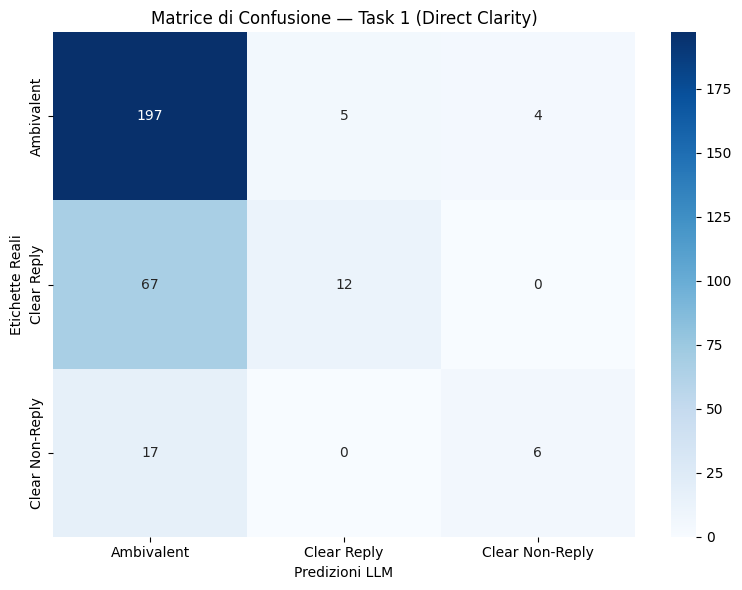


Grafico salvato in: ../results/task1/matrice_confusione_task1.png


<Figure size 640x480 with 0 Axes>

Salvataggio risultati tabellari in corso in: ../results/task1...
CSV salvato con successo: ../results/task1/predizioni_test_set_task1.csv


In [6]:
# ============================================================
# CELLA 6 — Analisi Performance
# ============================================================

y_true, y_pred = [], []

print(f"Valutazione su {len(test_dataset)} esempi...")

for i in tqdm(range(len(test_dataset))):
    esempio = test_dataset[i]
    y_true.append(str(esempio.get('clarity_label', '')).strip())

    try:
        pred = predici_clarity(esempio['interview_question'], esempio['interview_answer'])
        y_pred.append(pred)
    except Exception as e:
        print(f"Errore esempio {i}: {e}")
        y_pred.append("Error")

# ── Classification Report (3 cifre decimali) ─────────────────
print("\n" + "=" * 60)
print("REPORT FINALE — TASK 1 (CLARITY CLASSIFICATION)")
print("=" * 60)
print(classification_report(y_true, y_pred, labels=LABELS, digits=3))

# ── Matrice di Confusione ─────────────────────────────────────
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred, labels=LABELS)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel('Predizioni LLM')
plt.ylabel('Etichette Reali')
plt.title('Matrice di Confusione — Task 1 (Direct Clarity)')
plt.tight_layout()
plt.show()

# ── 1. SALVATAGGIO GRAFICO MATRICE DI CONFUSIONE ──
import os
os.makedirs(RES_DIR, exist_ok=True)
percorso_grafico = f"{TASK1_DIR}/matrice_confusione_task1.png"
plt.savefig(percorso_grafico, bbox_inches='tight', dpi=300)
print(f"\nGrafico salvato in: {percorso_grafico}")

plt.show() # Mostra il grafico a schermo dopo averlo salvato

# ── 2. SALVATAGGIO PREDIZIONI IN CSV ──
print(f"Salvataggio risultati tabellari in corso in: {TASK1_DIR}...")
df_risultati = pd.DataFrame({
    'Domanda': [ex.get('interview_question', '') for ex in test_dataset],
    'Risposta_Politico': [ex.get('interview_answer', '') for ex in test_dataset],
    'Vero_Task1_Clarity': y_true,
    'Predetto_Task1_Clarity': y_pred
})

percorso_csv = f"{TASK1_DIR}/predizioni_test_set_task1.csv"
df_risultati.to_csv(percorso_csv, index=False)
print(f"CSV salvato con successo: {percorso_csv}")

In [7]:
# ============================================================
# CELLA 7 — Metriche da CSV (Task 1)
# ============================================================

import os
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score

csv_path = os.path.join(TASK1_DIR, "predizioni_test_set_task1.csv")

if not os.path.exists(csv_path):
    print(f"CSV non trovato: {csv_path}")
else:
    df = pd.read_csv(csv_path)
    if {"Vero_Task1_Clarity", "Predetto_Task1_Clarity"}.issubset(df.columns):
        y_true = df["Vero_Task1_Clarity"].astype(str).str.strip()
        y_pred = df["Predetto_Task1_Clarity"].astype(str).str.strip()

        print("\n" + "=" * 60)
        print("REPORT FINALE — TASK 1 (CSV)")
        print("=" * 60)
        print(f"Accuracy: {accuracy_score(y_true, y_pred):.3f}")
        print(classification_report(y_true, y_pred, labels=LABELS, digits=3))
    else:
        print("Colonne mancanti nel CSV: Vero_Task1_Clarity, Predetto_Task1_Clarity")


REPORT FINALE — TASK 1 (CSV)
Accuracy: 0.698
                 precision    recall  f1-score   support

     Ambivalent      0.701     0.956     0.809       206
    Clear Reply      0.706     0.152     0.250        79
Clear Non-Reply      0.600     0.261     0.364        23

       accuracy                          0.698       308
      macro avg      0.669     0.456     0.474       308
   weighted avg      0.695     0.698     0.632       308

